# DCM labelling of scRNA-seq DEGs

This notebook evaluatues DCM labelling of DEGs identified in de scRNA-seq analysis.

## Input

- List of DEGs generated in notebook 8 (SupplementalTable3.txt)
- DCM scores per gene, available from GEO (GSE304236_DCMscores.genes.txt)

## Output

- Figure S5e: Boxplot of DCM scores of scRNA-seq DEGs
- Figure 3a: DCM labelling of top DEGs

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

## Load DCM scores of scRNA-seq DEGs

In [3]:
# DCM scores
dcm = pd.read_csv(f"{input_dir}/GSE304236_DCMscores.genes.txt", sep="\t", index_col=0, header=0)
dcm = dcm[dcm["NrSites"] > 10]
dcm = dcm[dcm["GeneName"] != "."]
dcm.index = dcm["GeneName"]
display(dcm)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,C6neg-2,C6neg-3,C6-1,...,T48,T72,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites
GeneName,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000620,0.001612,0.003014,0.042822,0.039482,0.048462,0.001442,0.000000,0.000000,0.046142,...,0.000000,0.000000,0.001749,0.006315,0.043589,0.018845,0.048050,0.012696,TSPAN6,38
TNMD,0.000575,0.000000,0.000000,0.038807,0.034341,0.040833,0.000000,0.001415,0.000705,0.033411,...,0.039010,0.000000,0.000192,0.003627,0.037994,0.008884,0.023858,0.005416,TNMD,41
DPM1,0.004438,0.005045,0.002021,0.103165,0.083093,0.087647,0.004512,0.002730,0.003061,0.086059,...,0.018816,0.000000,0.003835,0.032069,0.091302,0.045974,0.055403,0.055444,DPM1,85
SCYL3,0.001331,0.003211,0.002309,0.051179,0.057704,0.045904,0.002651,0.002339,0.003963,0.047282,...,0.000000,0.000000,0.002284,0.014743,0.051596,0.023948,0.051521,0.034199,SCYL3,124
C1orf112,0.001804,0.002180,0.002140,0.035357,0.040372,0.042450,0.002047,0.001703,0.002777,0.037439,...,0.005692,0.015669,0.002041,0.013985,0.039393,0.022678,0.036709,0.026909,C1orf112,562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMG1P7,0.047153,0.019692,0.024539,0.138187,0.089029,0.091680,0.041089,0.018646,0.010324,0.103718,...,0.429924,0.000000,0.030462,0.177051,0.106298,0.147911,0.069065,0.100861,SMG1P7,14
SMG1P5,0.002655,0.004829,0.004256,0.094638,0.090974,0.089112,0.003702,0.001698,0.003646,0.091200,...,0.048726,0.000000,0.003913,0.030101,0.091575,0.046383,0.075609,0.060821,SMG1P5,222
ANKRD20A11P,0.005164,0.001167,0.002999,0.017392,0.019784,0.017539,0.001826,0.004144,0.004680,0.020352,...,0.000000,0.000000,0.003110,0.030013,0.018238,0.031264,0.023170,0.027319,ANKRD20A11P,105


In [4]:
# scRNA-seq DEGs
degs = pd.read_csv(f"{output_dir}/SupplementalTable3.txt", sep="\t")
degs = degs[(degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]
display(degs)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,iPSC,SFRP2,26.595260,8.284877,7.701220e-156,1.507187e-151
1,iPSC,ERVH-1,26.592836,8.634070,8.215121e-156,1.507187e-151
2,iPSC,DNMT3B,26.526022,3.846034,4.857166e-155,5.940800e-151
3,iPSC,TERF1,26.514334,3.496398,6.624909e-155,6.077194e-151
4,iPSC,SOX2,26.330430,8.206783,8.600517e-153,5.259646e-149
...,...,...,...,...,...,...
76496,PGT,TMEM8B,3.242991,1.104018,1.182821e-03,9.053244e-03
76508,PGT,NPC1L1,3.233302,4.781400,1.223683e-03,9.334844e-03
76509,PGT,GRHL3,3.231057,4.554933,1.233335e-03,9.404565e-03
76521,PGT,SOD3,3.222076,2.485342,1.272651e-03,9.668199e-03


## Figure S5e: Boxplot of DCM scores of scRNA-seq DEGs

In [5]:
## Annotate with DEG category
ipsc_degs = degs[(degs["group"] == "iPSC") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]["names"]
de_degs = degs[(degs["group"] == "DE") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]["names"]
pgt_degs = degs[(degs["group"] == "PGT") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 1)]["names"]

dcm_degs = dcm.copy()
dcm_degs["DEGs"] = np.where(dcm_degs.index.isin(ipsc_degs), "iPSC",
                     np.where(dcm_degs.index.isin(de_degs), "DE",
                     np.where(dcm_degs.index.isin(pgt_degs), "PGT", "n.s.")))
dcm_degs["DEGs"] = pd.Categorical(dcm_degs["DEGs"], categories=labels + ["n.s."], ordered=True)
display(dcm_degs)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,C6neg-1,C6neg-2,C6neg-3,C6-1,...,T72,iPSC_nodox,iPSC_chase,iPSC_dox,DE_chase,DE_dox,PGT_chase,GeneName,NrSites,DEGs
GeneName,,,,,,,,,,,,,,,,,,,,,
TSPAN6,0.000620,0.001612,0.003014,0.042822,0.039482,0.048462,0.001442,0.000000,0.000000,0.046142,...,0.000000,0.001749,0.006315,0.043589,0.018845,0.048050,0.012696,TSPAN6,38,n.s.
TNMD,0.000575,0.000000,0.000000,0.038807,0.034341,0.040833,0.000000,0.001415,0.000705,0.033411,...,0.000000,0.000192,0.003627,0.037994,0.008884,0.023858,0.005416,TNMD,41,n.s.
DPM1,0.004438,0.005045,0.002021,0.103165,0.083093,0.087647,0.004512,0.002730,0.003061,0.086059,...,0.000000,0.003835,0.032069,0.091302,0.045974,0.055403,0.055444,DPM1,85,n.s.
SCYL3,0.001331,0.003211,0.002309,0.051179,0.057704,0.045904,0.002651,0.002339,0.003963,0.047282,...,0.000000,0.002284,0.014743,0.051596,0.023948,0.051521,0.034199,SCYL3,124,n.s.
C1orf112,0.001804,0.002180,0.002140,0.035357,0.040372,0.042450,0.002047,0.001703,0.002777,0.037439,...,0.015669,0.002041,0.013985,0.039393,0.022678,0.036709,0.026909,C1orf112,562,iPSC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMG1P7,0.047153,0.019692,0.024539,0.138187,0.089029,0.091680,0.041089,0.018646,0.010324,0.103718,...,0.000000,0.030462,0.177051,0.106298,0.147911,0.069065,0.100861,SMG1P7,14,n.s.
SMG1P5,0.002655,0.004829,0.004256,0.094638,0.090974,0.089112,0.003702,0.001698,0.003646,0.091200,...,0.000000,0.003913,0.030101,0.091575,0.046383,0.075609,0.060821,SMG1P5,222,n.s.
ANKRD20A11P,0.005164,0.001167,0.002999,0.017392,0.019784,0.017539,0.001826,0.004144,0.004680,0.020352,...,0.000000,0.003110,0.030013,0.018238,0.031264,0.023170,0.027319,ANKRD20A11P,105,n.s.


In [7]:
# Prepare df and calculate p-value between DEGs in iPSCs and DE
dcm_df = dcm_degs.melt(id_vars="DEGs", value_vars=["iPSC_nodox", "iPSC_dox", "DE_dox"])
dcm_df["DEGs"] = dcm_df["DEGs"].cat.remove_categories("n.s.")
display(dcm_df)

p_values = []
for sample in ["iPSC_dox", "DE_dox"]:
    iPSC_values = dcm_df[(dcm_df["variable"] == sample) & (dcm_df["DEGs"] == "iPSC")]["value"].tolist()
    DE_values = dcm_df[(dcm_df["variable"] == sample) & (dcm_df["DEGs"] == "DE")]["value"].tolist()
    stat, p_value = scipy.stats.mannwhitneyu(iPSC_values, DE_values, alternative="two-sided")
    print(f"{sample}: {p_value}")
    p_values.append(p_value)

_, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="bonferroni")
print(pvals_corrected)

,DEGs,variable,value
0,NaN,iPSC_nodox,0.001749
1,NaN,iPSC_nodox,0.000192
2,NaN,iPSC_nodox,0.003835
3,NaN,iPSC_nodox,0.002284
4,iPSC,iPSC_nodox,0.002041
...,...,...,...
74890,NaN,DE_dox,0.069065
74891,NaN,DE_dox,0.075609
74892,NaN,DE_dox,0.023170
74893,NaN,DE_dox,0.020789


iPSC_dox: 2.6132579144776504e-17
DE_dox: 7.279082870891211e-77
[5.22651583e-17 1.45581657e-76]


/tmp/ipykernel_2211715/3408661080.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(["-dox", "iPSC\ndox", "DE\ndox"])


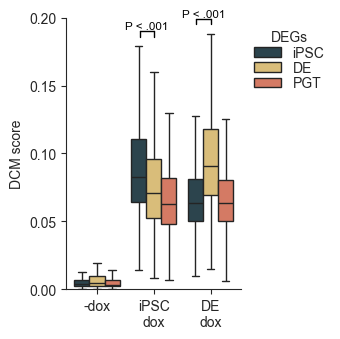

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(3.5, 3.5))
sns.boxplot(x="variable", y="value", hue="DEGs", palette=palette, data=dcm_df, ax=axs, showfliers=False)

axs.set_xlabel("")
axs.set_ylabel("DCM score")
axs.set_xticklabels(["-dox", "iPSC\ndox", "DE\ndox"])
axs.set_yticks([0, 0.05, 0.1, 0.15, 0.2])
axs.set_ylim(0, 0.2)

for axis, y1, y2, x1, x2, label in [[axs, 0.186, 0.19, 0.75, 1, "P < .001"], [axs, 0.195, 0.199, 1.75, 2, "P < .001"]]:
    axis.plot((x1, x2), (y2, y2), color="black", linewidth=1)
    axis.plot((x1, x1), (y1, y2), color="black", linewidth=1)
    axis.plot((x2, x2), (y1, y2), color="black", linewidth=1)
    axis.text((x1+x2)/2, y2, label, ha="center", va="bottom", color="black", fontsize="small")

axs.legend(frameon=False, title="DEGs", bbox_to_anchor=(1, 1), labelspacing=0.1)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure5e.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure 3a: DCM labelling of top DEGs

In [9]:
# top iPSC DEGs
ipsc_degs = degs[(degs["group"] == "iPSC") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 2)]["names"].tolist()
ipsc_degs = [gene for gene in ipsc_degs if gene in dcm.index][:15]

# top DE DEGs
de_degs = degs[(degs["group"] == "DE") & (degs["pvals_adj"] < 0.01) & (degs["logfoldchanges"] > 2)]["names"].tolist()
de_degs = [gene for gene in de_degs if gene in dcm.index][:15]

# DCM scores of top DEGs
dcm_degs = dcm.loc[ipsc_degs + de_degs]
print(dcm_degs.index)

Index(['SFRP2', 'ERVH-1', 'DNMT3B', 'TERF1', 'DPPA4', 'ESRG', 'UTF1', 'PSAT1',
       'DANCR', 'SEPHS1', 'NANOG', 'FABP5', 'C1QBP', 'DDX21', 'CD9', 'FGF17',
       'PTGR1', 'LEFTY1', 'EOMES', 'CNTNAP2', 'LEFTY2', 'PLSCR2', 'LINC01356',
       'SERPINB9', 'CYP26A1', 'SOX17', 'SFRP1', 'KCNK12', 'LINC00458',
       'MIXL1'],
      dtype='object', name='GeneName')


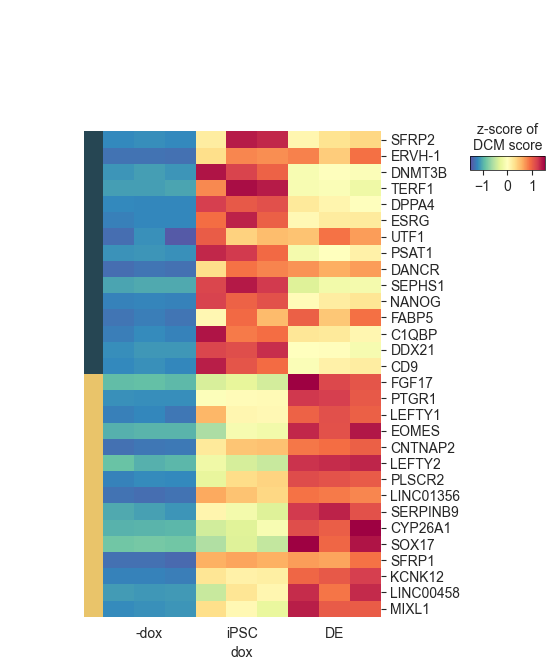

In [10]:
g = sns.clustermap(dcm_degs[["C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3", "DE-d1", "DE-d2", "DE-d3"]], cmap="Spectral_r", z_score=0,
                   cbar_kws={"shrink": .8, "label": "z-score of\nDCM score", "orientation": "horizontal"}, 
                   cbar_pos=(0.95, 0.75, 0.15, 0.02), vmin=-1.5, vmax=1.5,
                   figsize=(5, 7), row_cluster=False, col_cluster=False, yticklabels=1,
                   row_colors=[palette["iPSC"]]*len(ipsc_degs) + [palette["DE"]]*len(de_degs), colors_ratio=0.05)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("dox")
g.ax_heatmap.set_xticklabels(["", "-dox", "", "", "iPSC", "", "", "DE", ""], rotation=0)
g.ax_heatmap.tick_params(right=True, bottom=False)

# Tweak color bar
g.cax.xaxis.set_label_position("top")
for spine in g.cax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.5)

plt.savefig(f"{output_dir}/Figure3a_left.svg", format="svg", bbox_inches="tight")
plt.show()

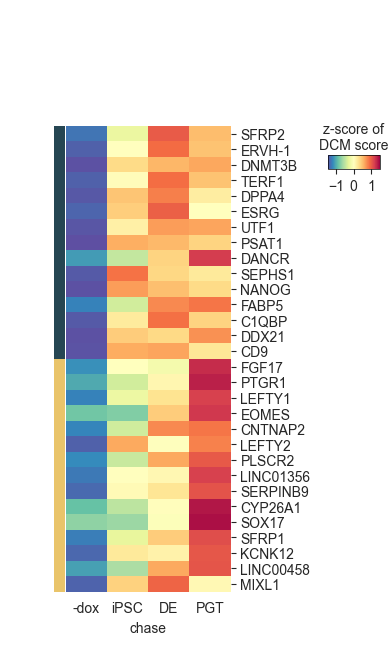

In [11]:
g = sns.clustermap(dcm_degs[["iPSC_nodox", "iPSC_chase", "DE_chase", "PGT_chase"]], 
                   cmap="Spectral_r", z_score=0, cbar_pos=(0.95, 0.75, 0.15, 0.02), vmin=-1.5, vmax=1.5,
                   cbar_kws={"shrink": .8, "label": "z-score of\nDCM score", "orientation": "horizontal"}, 
                   figsize=(3.5, 7), row_cluster=False, col_cluster=False, yticklabels=1,
                   row_colors=[palette["iPSC"]]*len(ipsc_degs) + [palette["DE"]]*len(de_degs), colors_ratio=0.05)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("chase")
g.ax_heatmap.set_xticklabels(["-dox", "iPSC", "DE", "PGT"], rotation=0)
g.ax_heatmap.tick_params(right=True, bottom=False)
                         
# Tweak color bar
g.cax.xaxis.set_label_position("top")
for spine in g.cax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.5)

plt.savefig(f"{output_dir}/Figure3a_right.svg", format="svg", bbox_inches="tight")
plt.show()